In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from collections import Counter
from sklearn.metrics import roc_auc_score
import tensorflow as tf
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, GlobalAveragePooling2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import backend as K
%load_ext autoreload
%autoreload

In [2]:
base_path = Path('C:\\Users\\deepi\\OneDrive\\Desktop\\project')
train_data_path = base_path / 'train'
test_data_path = base_path / 'test'
train_labels_path = base_path / 'train_labels.csv'

def load_data(file_path):
    try:
        return pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        return None

train_df = load_data(base_path / 'C:\\Users\\deepi\\OneDrive\\Desktop\\project\\CheXpert-v1.0-small\\train.csv')
valid_df = load_data(base_path / 'C:\\Users\\deepi\\OneDrive\\Desktop\\project\\CheXpert-v1.0-small\\valid.csv')

if train_df is not None:
    print("Training data loaded successfully.")
else:
    print("Failed to load training data.")

if valid_df is not None:
    print("Validation data loaded successfully.")
else:
    print("Failed to load validation data.")

Training data loaded successfully.
Validation data loaded successfully.


In [3]:
chexnet_targets = ['No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity',
                   'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis',
                   'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture',
                   'Support Devices']

chexpert_targets = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion']

In [4]:
train_df.head()

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [5]:
u_one_features = ['Atelectasis', 'Edema']
u_zero_features = ['Cardiomegaly', 'Consolidation', 'Pleural Effusion']

In [6]:
def feature_string(row):
    active_features = [
        feature for feature in u_one_features if row[feature] in [-1, 1]
    ] + [
        feature for feature in u_zero_features if row[feature] == 1
    ]
    
    return ';'.join(active_features)

In [7]:
train_df['train_valid'] = False
valid_df['train_valid'] = True

In [8]:
train_df['patient'] = train_df['Path'].str.split('/', expand=True)[2]
train_df['study'] = train_df['Path'].str.split('/', expand=True)[3]

valid_df['patient'] = valid_df['Path'].str.split('/', expand=True)[2]
valid_df['study'] = valid_df['Path'].str.split('/', expand=True)[3]

In [9]:
df = pd.concat([train_df, valid_df])
df.head()

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,...,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,train_valid,patient,study
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,NaN,1.0,False,patient00001,study1
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,...,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN,False,patient00002,study2
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,False,patient00002,study1
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,False,patient00002,study1
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,False,patient00003,study1


In [10]:
def feature_string(row):
    active_features = [
        feature for feature in u_one_features if row[feature] in [-1, 1]
    ] + [
        feature for feature in u_zero_features if row[feature] == 1
    ]
    
    if len(active_features) == 0:
        return None
    
    return ';'.join(active_features)

df['feature_string'] = df.apply(feature_string, axis=1)
df = df[df['feature_string'].notna()]
df['feature_string'] = df['feature_string'].apply(lambda x: x.split(";"))
df.head()

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,...,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,train_valid,patient,study,feature_string
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,...,-1.0,NaN,-1.0,NaN,1.0,NaN,False,patient00002,study2,"[Atelectasis, Edema]"
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,False,patient00003,study1,[Edema]
12,CheXpert-v1.0-small/train/patient00007/study1/...,Male,69,Frontal,AP,NaN,NaN,1.0,1.0,NaN,...,1.0,1.0,0.0,NaN,0.0,1.0,False,patient00007,study1,"[Atelectasis, Cardiomegaly]"
13,CheXpert-v1.0-small/train/patient00007/study2/...,Male,69,Frontal,AP,NaN,1.0,NaN,1.0,NaN,...,1.0,0.0,0.0,NaN,0.0,1.0,False,patient00007,study2,[Atelectasis]
14,CheXpert-v1.0-small/train/patient00008/study1/...,Male,81,Frontal,AP,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,1.0,NaN,NaN,1.0,False,patient00008,study1,[Pleural Effusion]


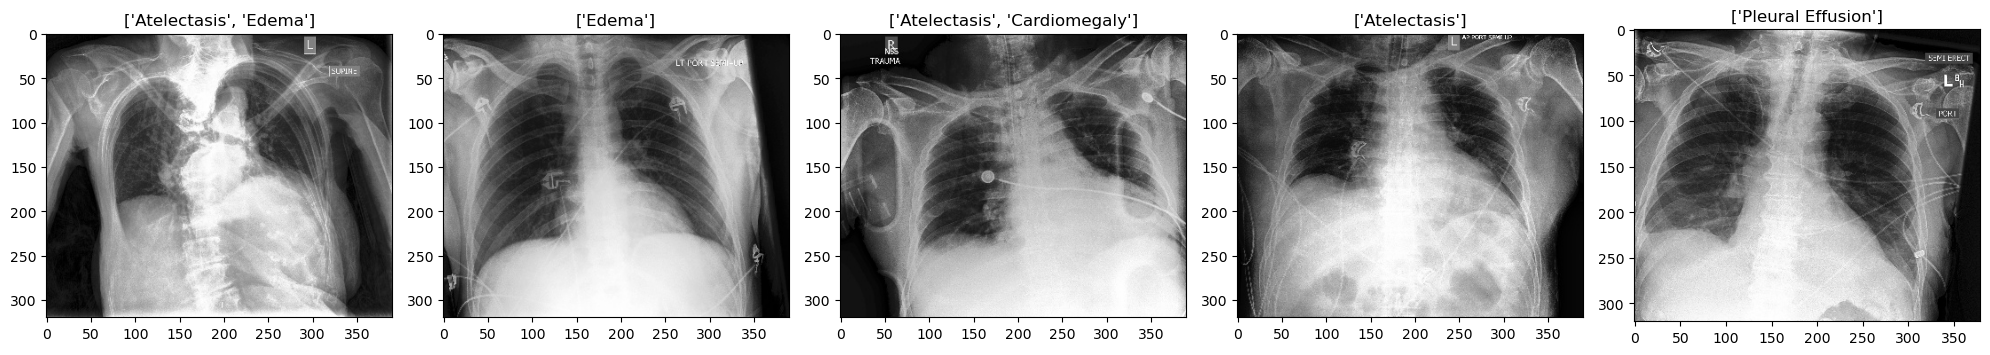

In [11]:
image_paths = df['Path'].head(5)
image_labels = df['feature_string'].head(5)
fig, axes = plt.subplots(1, len(image_labels), figsize=(20, 10))
for ax, path, label in zip(axes, image_paths, image_labels):
    image = cv2.imread(os.path.join(base_path, path))
    ax.imshow(image)
    ax.set_title(label)
plt.tight_layout()
plt.show()

In [12]:
print(f"Paths: {image_paths}")
print(f"Labels: {image_labels}")


Paths: 1     CheXpert-v1.0-small/train/patient00002/study2/...
4     CheXpert-v1.0-small/train/patient00003/study1/...
12    CheXpert-v1.0-small/train/patient00007/study1/...
13    CheXpert-v1.0-small/train/patient00007/study2/...
14    CheXpert-v1.0-small/train/patient00008/study1/...
Name: Path, dtype: object
Labels: 1            [Atelectasis, Edema]
4                         [Edema]
12    [Atelectasis, Cardiomegaly]
13                  [Atelectasis]
14             [Pleural Effusion]
Name: feature_string, dtype: object


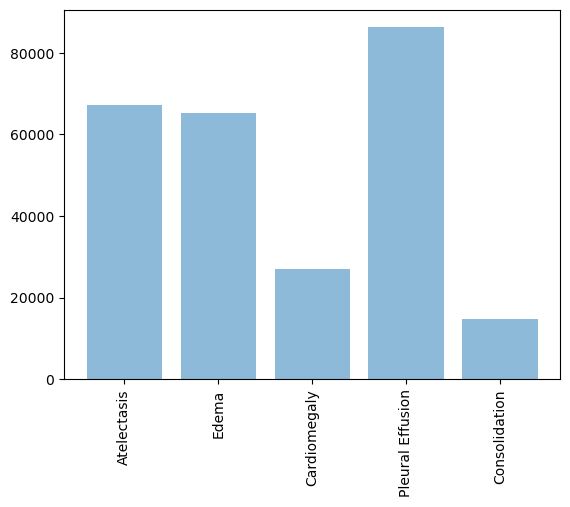

In [13]:
all_labels = [label for chexpert_targets in df['feature_string'] for label in chexpert_targets]
label_counts = Counter(all_labels)
plt.bar(label_counts.keys(), label_counts.values(), alpha=0.5)
plt.xticks(rotation='vertical')
plt.show()

In [14]:
sample_percentage = 0.00
train_df1 = df[~df['train_valid']]
valid_df1 = df[df['train_valid']]
unique_patients = train_df1['patient'].unique()
sample_mask = np.random.rand(len(unique_patients)) < sample_percentage
sampled_patients = unique_patients[sample_mask]
dev_set = train_df1[train_df1['patient'].isin(sampled_patients)]
train_set = train_df1[~train_df1['patient'].isin(sampled_patients)]
print(f"Validation set size: {valid_df1['Path'].size}")
print(f"Training set size: {train_set['Path'].size}")

Validation set size: 137
Training set size: 157281


In [15]:
train_set = train_set.sample(n=20000, random_state=42)

In [16]:
print(f"Training set size: {train_set['Path'].size}")

Training set size: 20000


In [17]:
datagen= ImageDataGenerator(rescale=1./255, 
                                 featurewise_center=True,
                                 featurewise_std_normalization=True,
                                 rotation_range=5,
                                 width_shift_range=0.2,
                                 height_shift_range=0.2,
                                 horizontal_flip=True,
                                 validation_split = 0.1)
test_datagen= ImageDataGenerator(rescale=1./255)

In [18]:
def generate_datasets(image_size = 75):

    train_generator=datagen.flow_from_dataframe(dataframe=train_set, directory=base_path, 
                                                x_col="Path", y_col="feature_string", has_ext=True, seed = 42, #classes = chexpert_targets,
                                                class_mode="categorical", target_size=(image_size,image_size), batch_size=32, subset = "training")

    validation_generator = datagen.flow_from_dataframe(dataframe=train_set, directory=base_path, 
                                                       x_col="Path", y_col="feature_string", has_ext=True, seed = 42, #classes = chexpert_targets,
                                                       class_mode="categorical", target_size=(image_size,image_size), batch_size=32, subset = "validation")

    test_generator = test_datagen.flow_from_dataframe(dataframe=valid_df1, directory=base_path, 
                                                      target_size=(image_size,image_size),class_mode='categorical',
                                                      batch_size=1, shuffle=False,
                                                      x_col="Path", y_col="feature_string")
    
    return [train_generator,validation_generator,test_generator]

In [19]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.metrics import AUC
import tensorflow as tf
from tensorflow.keras import backend as K

## EfficientNet

In [20]:
def build_model(image_size = 75, load_previous_weights = True, freeze_cnn = False):
    base_model = EfficientNetB0(include_top=False, input_shape=(image_size, image_size, 3), weights='imagenet')
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    predictions = Dense(5, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    if freeze_cnn:
        for layer in base_model.layers:
            layer.trainable = False

    model.compile(optimizer='adam', loss='categorical_crossentropy', 
                  metrics=['accuracy', AUC()])
    return model

In [21]:
image_size_input = 75
model = build_model(image_size=image_size_input)

In [22]:
datasets = generate_datasets(image_size=image_size_input)
train_generator, validation_generator, test_generator = datasets

Found 18000 validated image filenames belonging to 5 classes.
Found 2000 validated image filenames belonging to 5 classes.
Found 137 validated image filenames belonging to 5 classes.


In [23]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 75, 75, 3)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 75, 75, 3)         │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 75, 75, 3)         │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 75, 75, 3)         │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 77, 77, 3)         │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 38, 38, 32)        │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 38, 38, 32)        │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 38, 38, 32)        │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 38, 38, 32)        │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 38, 38, 32)        │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 38, 38, 32)        │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             288 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 5,894,824 (22.49 MB)

 Trainable params: 5,849,729 (22.31 MB)

 Non-trainable params: 45,095 (176.16 KB)

In [24]:
epochs = 10
STEP_SIZE_TRAIN = train_generator.n // train_generator.batch_size
STEP_SIZE_VALID = validation_generator.n // validation_generator.batch_size

In [25]:
history = model.fit(train_generator, steps_per_epoch=STEP_SIZE_TRAIN,
                    validation_data=validation_generator,
                    validation_steps=STEP_SIZE_VALID, epochs=epochs)

Epoch 1/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 515s 790ms/step - accuracy: 0.2574 - auc: 0.5370 - loss: 3.7753 - val_accuracy: 0.3201 - val_auc: 0.5031 - val_loss: 2.7463
Epoch 2/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2500 - auc: 0.5184 - loss: 2.9430 - val_accuracy: 0.5625 - val_auc: 0.5094 - val_loss: 2.3929
Epoch 3/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 401s 712ms/step - accuracy: 0.3890 - auc: 0.5281 - loss: 3.8711 - val_accuracy: 0.4284 - val_auc: 0.5000 - val_loss: 3.0669
Epoch 4/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 1s 455us/step - accuracy: 0.2812 - auc: 0.5889 - loss: 4.0198 - val_accuracy: 0.4375 - val_auc: 0.5000 - val_loss: 1.9946
Epoch 5/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 357s 635ms/step - accuracy: 0.4137 - auc: 0.5219 - loss: 4.0183 - val_accuracy: 0.4279 - val_auc: 0.5000 - val_loss: 3.0523
Epoch 6/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 1s 334us/step - accuracy: 0.3750 - auc: 0.5369 - loss: 6.2585 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 2.4498
Epoch 7/10
562/562 ━━━━━

In [26]:
STEP_SIZE_TEST = test_generator.n // test_generator.batch_size
test_loss, test_accuracy, test_auc = model.evaluate(test_generator, steps=STEP_SIZE_TEST)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")
print(f"Test AUC: {test_auc}")

137/137 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.5507 - auc: 0.5000 - loss: 3.8572
Test Loss: 4.17877721786499
Test Accuracy: 0.5839415788650513
Test AUC: 0.5


In [27]:
def plot_training_history(history):
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 3, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy over Epochs')
    plt.subplot(1, 3, 2)
    plt.plot(history.history['auc'], label='Train AUC')
    plt.plot(history.history['val_auc'], label='Validation AUC')
    plt.xlabel('Epochs')
    plt.ylabel('AUC')
    plt.legend()
    plt.title('AUC over Epochs')
    plt.subplot(1, 3, 3)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss over Epochs')
    plt.tight_layout()
    plt.show()

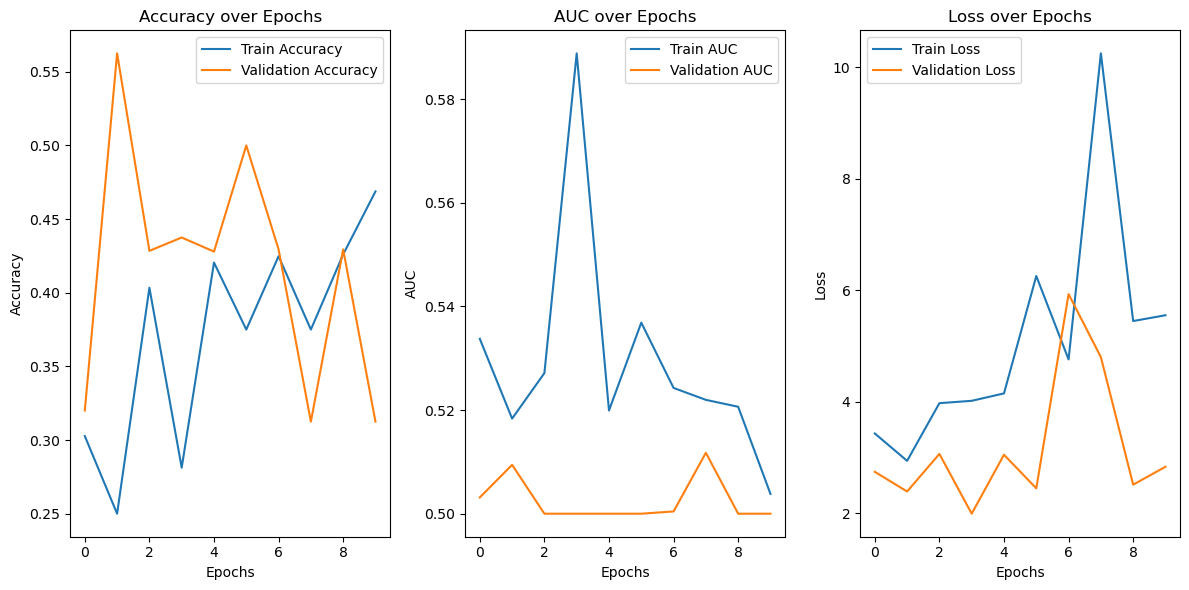

In [28]:
plot_training_history(history)

In [29]:
test_generator.reset() 
predictions = model.predict(test_generator, steps=STEP_SIZE_TEST, verbose=1)
predicted_classes = (predictions > 0.5).astype(int)
true_classes = test_generator.classes

137/137 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step


In [30]:
from sklearn.metrics import classification_report
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

true_classes_binary = mlb.fit_transform(true_classes)
predicted_classes_binary = mlb.transform(predicted_classes)

print("Classification Report:")
print(classification_report(true_classes_binary, predicted_classes_binary, target_names=test_generator.class_indices.keys()))

Classification Report:
                  precision    recall  f1-score   support

     Atelectasis       0.58      1.00      0.74        80
    Cardiomegaly       0.00      0.00      0.00        68
   Consolidation       0.00      0.00      0.00        33
           Edema       0.00      0.00      0.00        45
Pleural Effusion       0.00      0.00      0.00        67

       micro avg       0.58      0.27      0.37       293
       macro avg       0.12      0.20      0.15       293
    weighted avg       0.16      0.27      0.20       293
     samples avg       0.58      0.29      0.36       293



## DenseNet121

In [31]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.optimizers import Adam

def build_model_densenet(image_size = 75, load_previous_weights = True, freeze_cnn = False):
    base_model = DenseNet121(include_top=False, input_shape=(image_size, image_size, 3), weights='imagenet')
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    predictions = Dense(5, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    if freeze_cnn:
        for layer in base_model.layers:
            layer.trainable = False

    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy', AUC()])

    return model

In [32]:
image_size_input = 75
model = build_model_densenet(image_size=image_size_input)

In [33]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 75, 75, 3)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d                │ (None, 81, 81, 3)         │               0 │ input_layer_1[0][0]        │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 38, 38, 64)        │           9,408 │ zero_padding2d[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 38, 38, 64)        │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 38, 38, 64)        │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_1              │ (None, 40, 40, 64)        │               0 │ conv1_relu[0][0]           │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1 (MaxPooling2D)          │ (None, 19, 19, 64)        │               0 │ zero_padding2d_1[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_bn             │ (None, 19, 19, 64)        │             256 │ pool1[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_relu           │ (None, 19, 19, 64)        │               0 │ conv2_block1_0_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 19, 19, 128)       │           8,192 │ conv2_block1_0_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 19, 19, 128)       │             512 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 19, 19, 128)       │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 19, 19, 32)        │          36,864 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_concat           │ (None, 19, 19, 96)        │               0 │ pool1[0][0],               │
│ (Concatenate)                 │                           │               

 Total params: 8,620,613 (32.89 MB)

 Trainable params: 8,533,893 (32.55 MB)

 Non-trainable params: 86,720 (338.75 KB)

In [34]:
history = model.fit(train_generator, steps_per_epoch=STEP_SIZE_TRAIN,
                    validation_data=validation_generator,
                    validation_steps=STEP_SIZE_VALID, epochs=epochs)

Epoch 1/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 980s 2s/step - accuracy: 0.2633 - auc_1: 0.5434 - loss: 3.6466 - val_accuracy: 0.4073 - val_auc_1: 0.5214 - val_loss: 7.0642
Epoch 2/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2812 - auc_1: 0.4940 - loss: 4.6685 - val_accuracy: 0.5000 - val_auc_1: 0.4836 - val_loss: 18.8242
Epoch 3/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 868s 2s/step - accuracy: 0.3952 - auc_1: 0.5329 - loss: 3.7889 - val_accuracy: 0.4289 - val_auc_1: 0.4993 - val_loss: 519.2183
Epoch 4/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step - accuracy: 0.3125 - auc_1: 0.5570 - loss: 3.7347 - val_accuracy: 0.3750 - val_auc_1: 0.5000 - val_loss: 908.7999
Epoch 5/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 836s 1s/step - accuracy: 0.4170 - auc_1: 0.5198 - loss: 3.9916 - val_accuracy: 0.4284 - val_auc_1: 0.5299 - val_loss: 4.1993
Epoch 6/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 2s 779us/step - accuracy: 0.5938 - auc_1: 0.5467 - loss: 3.8194 - val_accuracy: 0.3750 - val_auc_1: 0.5577 - val_loss: 4.9704
Epoc

In [35]:
STEP_SIZE_TEST = test_generator.n // test_generator.batch_size
test_loss, test_accuracy, test_auc = model.evaluate(test_generator, steps=STEP_SIZE_TEST)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")
print(f"Test AUC: {test_auc}")

137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.5507 - auc_1: 0.5564 - loss: 7.4370
Test Loss: 8.004148483276367
Test Accuracy: 0.5839415788650513
Test AUC: 0.5502977967262268


In [36]:
def plot_training_history(history):
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 3, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy over Epochs')
    plt.subplot(1, 3, 2)
    plt.plot(history.history['auc_1'], label='Train AUC')
    plt.plot(history.history['val_auc_1'], label='Validation AUC')
    plt.xlabel('Epochs')
    plt.ylabel('AUC')
    plt.legend()
    plt.title('AUC over Epochs')
    plt.subplot(1, 3, 3)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss over Epochs')
    plt.tight_layout()
    plt.show()

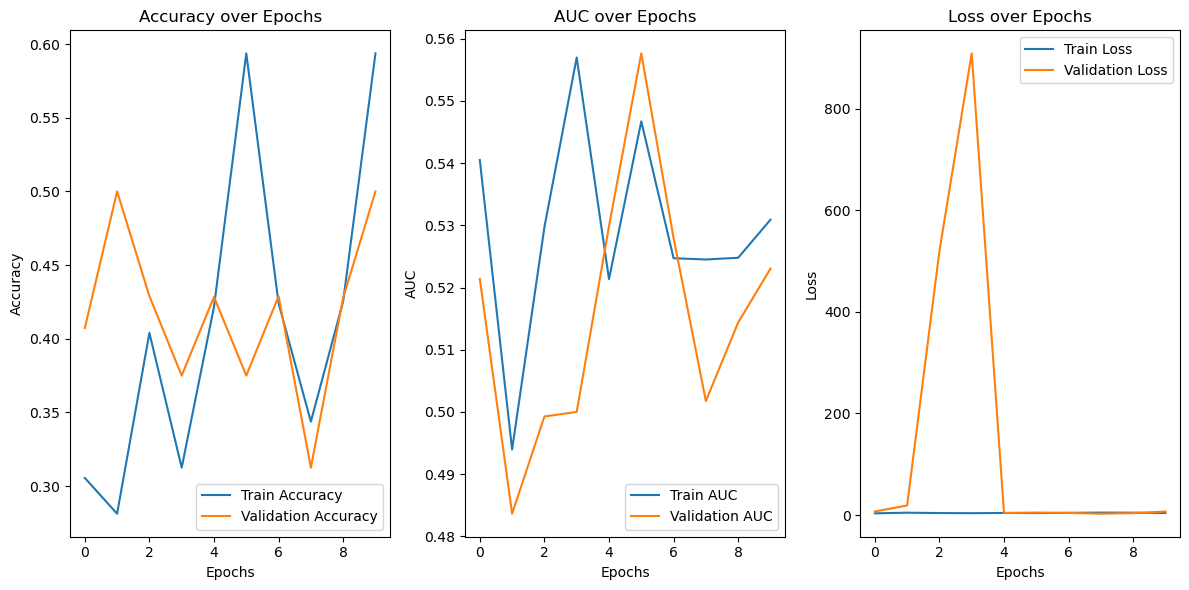

In [37]:
plot_training_history(history)

In [38]:
test_generator.reset() 
predictions = model.predict(test_generator, steps=STEP_SIZE_TEST, verbose=1)
predicted_classes = (predictions > 0.5).astype(int)
true_classes = test_generator.classes

137/137 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step


In [39]:
mlb = MultiLabelBinarizer()

true_classes_binary = mlb.fit_transform(true_classes)
predicted_classes_binary = mlb.transform(predicted_classes)

print("Classification Report:")
print(classification_report(true_classes_binary, predicted_classes_binary, target_names=test_generator.class_indices.keys()))

Classification Report:
                  precision    recall  f1-score   support

     Atelectasis       0.52      0.14      0.22        80
    Cardiomegaly       0.53      0.90      0.66        68
   Consolidation       0.00      0.00      0.00        33
           Edema       0.00      0.00      0.00        45
Pleural Effusion       0.00      0.00      0.00        67

       micro avg       0.53      0.25      0.33       293
       macro avg       0.21      0.21      0.18       293
    weighted avg       0.27      0.25      0.21       293
     samples avg       0.53      0.28      0.34       293



## Custom CNN

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout

In [41]:
def build_model_cnn(image_size=75, num_classes=5, load_previous_weights=True, freeze_cnn=False):
    model = Sequential()

    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(image_size, image_size, 3)))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())

    model.add(Dense(1024, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy', AUC()])

    return model

In [42]:
image_size_input = 75
model = build_model_cnn(image_size=image_size_input)

In [43]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 73, 73, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 36, 36, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 34, 34, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 17, 17, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 15, 15, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1024)                │       6,423,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 5)                   │           2,565 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,050,309 (26.89 MB)

 Trainable params: 7,047,237 (26.88 MB)

 Non-trainable params: 3,072 (12.00 KB)

In [44]:
epochs = 10
STEP_SIZE_TRAIN = train_generator.n // train_generator.batch_size
STEP_SIZE_VALID = validation_generator.n // validation_generator.batch_size

In [45]:
history = model.fit(train_generator, steps_per_epoch=STEP_SIZE_TRAIN,
                    validation_data=validation_generator,
                    validation_steps=STEP_SIZE_VALID, epochs=epochs)

Epoch 1/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 178s 310ms/step - accuracy: 0.2346 - auc_2: 0.5948 - loss: 3.7778 - val_accuracy: 0.3175 - val_auc_2: 0.6714 - val_loss: 2.9647
Epoch 2/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 302us/step - accuracy: 0.1875 - auc_2: 0.7331 - loss: 3.0562 - val_accuracy: 0.2500 - val_auc_2: 0.6646 - val_loss: 2.3883
Epoch 3/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 181s 322ms/step - accuracy: 0.2573 - auc_2: 0.6629 - loss: 3.3054 - val_accuracy: 0.2046 - val_auc_2: 0.6978 - val_loss: 4.1839
Epoch 4/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 153us/step - accuracy: 0.2500 - auc_2: 0.6421 - loss: 3.8973 - val_accuracy: 0.5625 - val_auc_2: 0.7707 - val_loss: 3.6062
Epoch 5/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 185s 329ms/step - accuracy: 0.2526 - auc_2: 0.6653 - loss: 3.6479 - val_accuracy: 0.3599 - val_auc_2: 0.7088 - val_loss: 2.7554
Epoch 6/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 192us/step - accuracy: 0.2500 - auc_2: 0.6931 - loss: 2.8131 - val_accuracy: 0.3750 - val_auc_2: 0.6464 - val_loss: 3.564

In [50]:
STEP_SIZE_TEST = test_generator.n // test_generator.batch_size
test_loss, test_accuracy, test_auc = model.evaluate(test_generator, steps=STEP_SIZE_TEST)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")
print(f"Test AUC: {test_auc}")

137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1313 - auc_2: 0.5330 - loss: 7.4497
Test Loss: 8.229663848876953
Test Accuracy: 0.08029197156429291
Test AUC: 0.5324711203575134


In [51]:
def plot_training_history(history):
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 3, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy over Epochs')
    plt.subplot(1, 3, 2)
    plt.plot(history.history['auc_2'], label='Train AUC')
    plt.plot(history.history['val_auc_2'], label='Validation AUC')
    plt.xlabel('Epochs')
    plt.ylabel('AUC')
    plt.legend()
    plt.title('AUC over Epochs')
    plt.subplot(1, 3, 3)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss over Epochs')
    plt.tight_layout()
    plt.show()

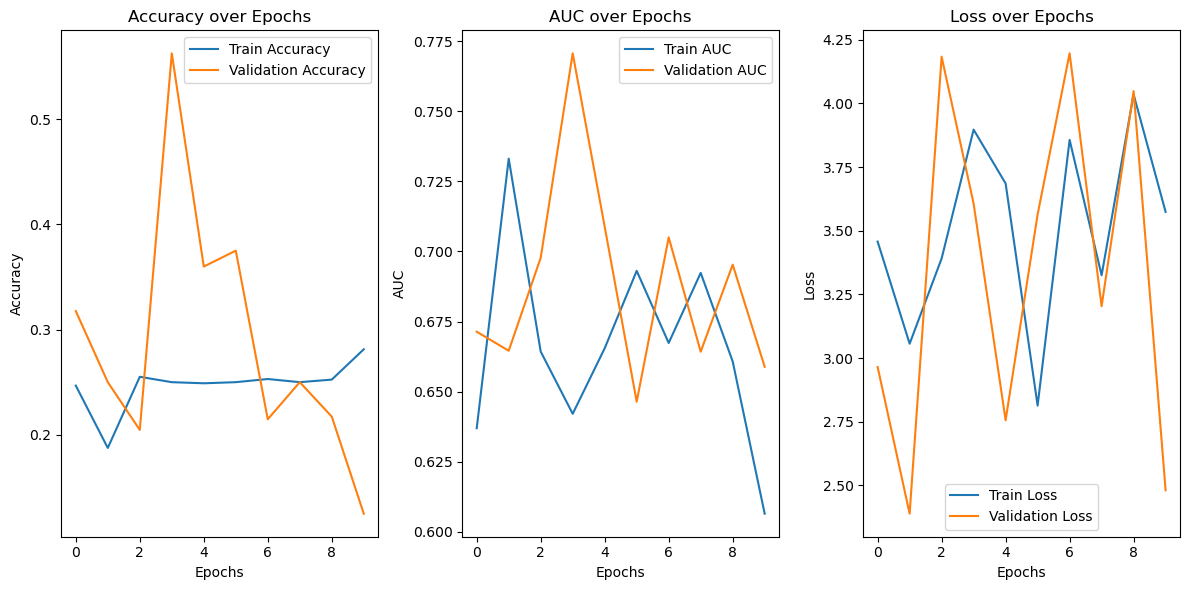

In [52]:
plot_training_history(history)

In [53]:
test_generator.reset() 
predictions = model.predict(test_generator, steps=STEP_SIZE_TEST, verbose=1)
predicted_classes = (predictions > 0.5).astype(int)
true_classes = test_generator.classes

137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [54]:
mlb = MultiLabelBinarizer()

true_classes_binary = mlb.fit_transform(true_classes)
predicted_classes_binary = mlb.transform(predicted_classes)

print("Classification Report:")
print(classification_report(true_classes_binary, predicted_classes_binary, target_names=test_generator.class_indices.keys()))

Classification Report:
                  precision    recall  f1-score   support

     Atelectasis       0.58      1.00      0.74        80
    Cardiomegaly       0.58      0.50      0.54        68
   Consolidation       0.00      0.00      0.00        33
           Edema       0.00      0.00      0.00        45
Pleural Effusion       0.00      0.00      0.00        67

       micro avg       0.58      0.39      0.47       293
       macro avg       0.23      0.30      0.25       293
    weighted avg       0.29      0.39      0.33       293
     samples avg       0.56      0.39      0.44       293

